#**1. Tìm hiểu về Class Python**

In [ ]:
# Tạo một class đơn giản 1 
class Dog:
  def __init__(self, name): #hàm tạo 
    self.name = name #biến 1
  def __str__(self): #định nghĩa giá trị khi gọi trực tiêp đối tượng được tạo ra từ class 
        return self.name
  def __call__(self, a, b): 
    return a*b
  def print_name(self):
    print(self.name)
meo = Dog("mèo")
meo.print_name()
print(meo.name)
print(meo)
print(meo(10,5))

In [10]:
# Tạo một class đơn giản 2 
class Dog:
  def __init__(self, name): #hàm tạo 
    self.name = name #biến 1
  def __str__(self): #định nghĩa giá trị khi gọi trực tiêp đối tượng được tạo ra từ class 
        return self.name
  def call(self, a, b):
    return a*b
  def print_name(self):
    print(self.name)
meo = Dog("mèo")
meo.print_name()
print(meo.name)
print(meo)
print(meo.call(10,5))

mèo
mèo
mèo
50


#**2.Tìm hiểu về tensorflow_hub**

In [ ]:
content_path = tf.keras.utils.get_file('Anh-2.jpg', 'https://i.ibb.co/rGS42y1/Anh-2.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

195196/195196 [==============================] - 0s 0us/step


## **Đọc cách 1**

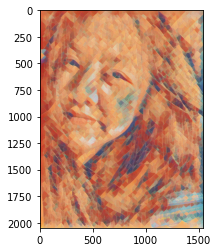

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
content_image_path = tf.keras.utils.get_file('Anh-2.jpg', 'https://i.ibb.co/rGS42y1/Anh-2.jpg')
# style_image_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')
style_image_path = tf.keras.utils.get_file('background-vintage-14.jpg','https://i.ibb.co/7kFyzWn/background-vintage-14.jpg')
# Load content and style images (see example in the attached colab).
content_image = plt.imread(content_image_path)
style_image = plt.imread(style_image_path)
# Convert to float32 numpy array, add batch dimension, and normalize to range [0, 1]. Example using numpy:
content_image = content_image.astype(np.float32)[np.newaxis, ...] / 255.
style_image = style_image.astype(np.float32)[np.newaxis, ...] / 255.
# Optionally resize the images. It is recommended that the style image is about
# 256 pixels (this size was used when training the style transfer network).
# The content image can be any size.
style_image = tf.image.resize(style_image, (256, 256))

# Load image stylization module.
hub_module = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Stylize image.
outputs = hub_module(tf.constant(content_image), tf.constant(style_image))
stylized_image = outputs[0]

img_new = tf.cast(stylized_image[0]*255, tf.int32)
plt.imshow(img_new)
plt.show()

## **Đọc cách 2**

In [ ]:
content_path = tf.keras.utils.get_file('Anh-2.jpg', 'https://i.ibb.co/rGS42y1/Anh-2.jpg')
style_path = tf.keras.utils.get_file('background-vintage-14.jpg','https://i.ibb.co/7kFyzWn/background-vintage-14.jpg')

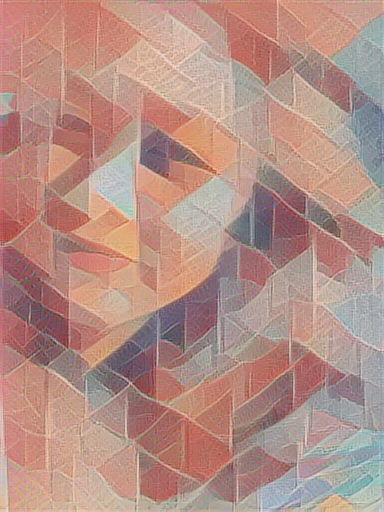

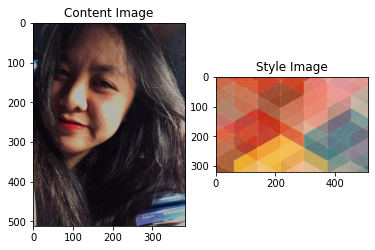

In [ ]:
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img) 
  img = tf.image.decode_image(img, channels=3) 
  img = tf.image.convert_image_dtype(img, tf.float32) 

  shape = tf.cast(tf.shape(img)[:-1], tf.float32) 
  long_dim = max(shape) 
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :] 
  return img
def imshow(image, title=None): 
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0) 

  plt.imshow(image)
  if title:
    plt.title(title)
def tensor_to_image(tensor): 
  import PIL.Image
  tensor = tensor*255 
  tensor = np.array(tensor, dtype=np.uint8) 
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

# hiển thị ảnh lúc đọc
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

import tensorflow_hub as hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image)) 
stylized_image = stylized_image[0] 
tensor_to_image(stylized_image)

## **Bài toán khác**

In [ ]:
import os
from pprint import pprint
from six import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from PIL import Image, ImageColor, ImageDraw, ImageFont, ImageOps
from tqdm import tqdm
# Load compressed models from tensorflow_hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

detector = hub.load("https://tfhub.dev/tensorflow/faster_rcnn/inception_resnet_v2_640x640/1") 
# The input tensor is a tf.uint8 tensor with shape [1, height, width, 3] with values in [0, 255].

def load_img_new(path_to_img):
  img = tf.io.read_file(path_to_img) 
  img = tf.image.decode_image(img, channels=3) 
  img = img[tf.newaxis, :] 
  # new_img = tf.cast(img, tf.uint8)
  return img # new_img
content_path = tf.keras.utils.get_file('Anh-2.jpg', 'https://i.ibb.co/rGS42y1/Anh-2.jpg')

image_tensor  = load_img_new(content_path)
detector_output = detector(image_tensor)
class_ids = detector_output["detection_classes"]

In [ ]:
detector_output.keys()

dict_keys(['detection_boxes', 'raw_detection_boxes', 'detection_classes', 'detection_anchor_indices', 'detection_multiclass_scores', 'detection_scores', 'num_detections', 'raw_detection_scores'])

- num_detections: a tf.int tensor with only one value, the number of detections [N].
- detection_boxes: a tf.float32 tensor of shape [N, 4] containing bounding box coordinates in the following order: [ymin, xmin, ymax, xmax].
- detection_classes: a tf.int tensor of shape [N] containing detection class index from the label file.
- detection_scores: a tf.float32 tensor of shape [N] containing detection scores.
- raw_detection_boxes: a tf.float32 tensor of shape [1, M, 4] containing decoded detection boxes without Non-Max suppression. M is the number of raw detections.
- raw_detection_scores: a tf.float32 tensor of shape [1, M, 90] and contains class score logits for raw detection boxes. M is the number of raw detections.
detection_anchor_indices: a tf.float32 tensor of shape [N] and contains the anchor indices of the detections after NMS.
- detection_multiclass_scores: a tf.float32 tensor of shape [1, N, 90] and contains class score distribution (including background) for detection boxes in the image including background class. 

#**3.Tìm hiểu về tensorflow trong bài**

In [2]:
import os
import tensorflow as tf
# Load compressed models from tensorflow_hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import PIL.Image
import time
import functools

In [3]:
content_path = tf.keras.utils.get_file('Anh-2.jpg', 'https://i.ibb.co/rGS42y1/Anh-2.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img) 
  img = tf.image.decode_image(img, channels=3) 
  img = tf.image.convert_image_dtype(img, tf.float32) 

  shape = tf.cast(tf.shape(img)[:-1], tf.float32) 
  long_dim = max(shape) 
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32) 
  img = tf.image.resize(img, new_shape) 
  img = img[tf.newaxis, :] 
  return img

195196/195196 [==============================] - 0s 0us/step


In [4]:
content_image = load_img(content_path)
print(content_image.shape)
style_image = load_img(style_path)
print(style_image.shape)

(1, 512, 384, 3)
(1, 336, 512, 3)


In [5]:
x = tf.keras.applications.vgg19.preprocess_input(content_image*255) 
x = tf.image.resize(x, (224, 224)) 
vgg = tf.keras.applications.VGG19(include_top=True, weights='imagenet') 
prediction_probabilities = vgg(x) 
prediction_probabilities.shape

574710816/574710816 [==============================] - 37s 0us/step


TensorShape([1, 1000])

In [7]:
vgg.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [6]:
predicted_top_5 = tf.keras.applications.vgg19.decode_predictions(prediction_probabilities.numpy())[0]
[(class_name, prob) for (number, class_name, prob) in predicted_top_5]

35363/35363 [==============================] - 0s 0us/step


[('seat_belt', 0.15828596),
 ('wig', 0.09755264),
 ('fur_coat', 0.064533144),
 ('hair_spray', 0.06029126),
 ('lipstick', 0.046843532)]



1.   **tf.keras.applications.vgg19.decode_predictions** 
- trả về đánh giá của mô hình khi học với dữ liệu **Imagenet**
- trả về một mảng 1 phần tử, bên trong gồm các **tuple(tên lớp, mô tả, và điểm)**  


In [ ]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

print()
for layer in vgg.layers:
  print(layer.name,end= ", ")

80134624/80134624 [==============================] - 5s 0us/step

input_2, block1_conv1, block1_conv2, block1_pool, block2_conv1, block2_conv2, block2_pool, block3_conv1, block3_conv2, block3_conv3, block3_conv4, block3_pool, block4_conv1, block4_conv2, block4_conv3, block4_conv4, block4_pool, block5_conv1, block5_conv2, block5_conv3, block5_conv4, block5_pool, 

1.  **tf.keras.applications.VGG19(include_top=False)** thì input_shape = (None, None, None, 3)

In [ ]:
vgg.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [16]:
content_layers = ['block5_conv2'] # (None, None, None, 512)

style_layers = ['block1_conv1', # (None, None, None, 64)
                'block2_conv1', # (None, None, None, 128)
                'block3_conv1', # (None, None, None, 256)
                'block4_conv1', # (None, None, None, 512)
                'block5_conv1'] # (None, None, None, 512)

num_content_layers = len(content_layers) # lấy 1 layer dùng cho ảnh content 
num_style_layers = len(style_layers)  # lấy 5 layer dùng cho ảnh style

In [17]:
content_layers + style_layers

['block5_conv2',
 'block1_conv1',
 'block2_conv1',
 'block3_conv1',
 'block4_conv1',
 'block5_conv1']

In [ ]:
def vgg_layers(layer_names):
  """ Creates a VGG model that returns a list of intermediate output values."""
  # Load our model. Load pretrained VGG, trained on ImageNet data
  vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
  vgg.trainable = False  
  
  outputs = [vgg.get_layer(name).output for name in layer_names]  

  model = tf.keras.Model([vgg.input], outputs) 
  return model

In [ ]:
style_extractor = vgg_layers(style_layers) 
style_outputs = style_extractor(style_image*255) 

In [ ]:
style_extractor = vgg_layers(style_layers) 
style_outputs = style_extractor(style_image*255) 

# một số thống kê về 5 đầu ra 
for name, output in zip(style_layers, style_outputs): # name in style_layers, output in style_outputs
  print(name)
  print("  shape: ", output.numpy().shape)
  print("  min: ", output.numpy().min())
  print("  max: ", output.numpy().max())
  print("  mean: ", output.numpy().mean())
  print()

block1_conv1
  shape:  (1, 336, 512, 64)
  min:  0.0
  max:  835.5256
  mean:  33.97525

block2_conv1
  shape:  (1, 168, 256, 128)
  min:  0.0
  max:  4625.8857
  mean:  199.82687

block3_conv1
  shape:  (1, 84, 128, 256)
  min:  0.0
  max:  8789.239
  mean:  230.78099

block4_conv1
  shape:  (1, 42, 64, 512)
  min:  0.0
  max:  21566.135
  mean:  791.24005

block5_conv1
  shape:  (1, 21, 32, 512)
  min:  0.0
  max:  3189.2542
  mean:  59.179478



In [30]:
image = tf.Variable(content_image)
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0) 
#đề phòng khi các phần tử trong ảnh nằm ngoài khoảng (0,1)

In [31]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

## Mô tả thuật toán Adam
*   Adam
 * Trong một bài toán tối ưu thường gặp, ta muốn thuật toán của mình đầu tiên vượt qua những local minimum nhiễu một cách dễ dàng, nhưng khi đạt được global minimum thì sẽ không dao động quá lâu mà tìm được vị trí phù hợp ngay. Điều này thúc đẩy ta tìm kiếm một thuật có hành vi được mô tả như trên.

 * Có một thuật toán đã hội tụ đủ mọi ưu điểm của những phương pháp trước đó, đó chính là Adam, được sử dụng rất phổ biến trong bài toán deep learning. Thuật toán của Adam được ví như một quả bóng có khối lượng lớn và có ma sát vì nó có động lượng rò rỉ để vượt qua các local minimum để tiến đến gobal ninimum và không dao động lâu vì có ma sát kế thừa từ AdaGrad
*  


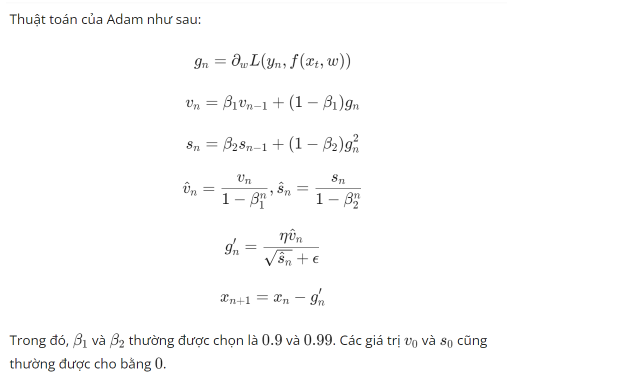

#**4.Lan truyền ngược** (backward and forward) 

Chúng a được cho một hàm f(x) trong đó x là một vector của dữ liệu và chúng ta muốn tính đạo hàm của f theo x (i.e. ∇f(x).)

Tính gradient của các tham số mạng nơ-ron. Phương thức này duyệt qua mạng nơ-ron theo chiều ngược lại, từ đầu ra đến đầu vào, tuân theo quy tắc dây chuyền trong giải tích.

Thuật toán lan truyền ngược lưu trữ các biến trung gian (là các đạo hàm riêng) cần thiết trong quá trình tính toán gradient theo các tham số. Giả sử chúng ta có hàm  Y=f(X)  và  Z=g(Y)=g∘f(X) , trong đó đầu vào và đầu ra  X,Y,Z  là các tensor có kích thước bất kỳ. Bằng cách sử dụng quy tắc dây chuyền, chúng ta có thể tính đạo hàm của  Z  theo  X  như sau:
$\frac{∂Z}{∂X}$ = prod($\frac{∂Z}{∂Y}$,$\frac{∂Y}{∂X}$)

# **5.gram_matrixt**

## Calculate style

The content of an image is represented by the values of the intermediate feature maps.

It turns out, the style of an image can be described by the means and correlations across the different feature maps.**(phong cách của một hình ảnh có thể được mô tả bằng các phương tiện và mối tương quan giữa các các đặc trưng trích ra được từ tấm ảnh khác nhau.)** Calculate a Gram matrix that includes this information by taking the outer product of the feature vector with itself at each location, and averaging that outer product over all locations. This Gram matrix can be calculated for a particular layer as:

$$G^l_{cd} = \frac{\sum_{ij} F^l_{ijc}(x)F^l_{ijd}(x)}{IJ}$$

This can be implemented concisely using the `tf.linalg.einsum` function:




***tf.linalg.einsum***

In [ ]:
import tensorflow as tf
con_lis = tf.convert_to_tensor([145,56,89,56])
print(con_lis)
m0 = tf.random.normal(shape=[2, 3])
m1 = tf.random.normal(shape=[3, 5])
e = tf.einsum('ij,jk->ik', m0, m1)
# output[i,k] = sum_j m0[i,j] * m1[j, k]
print(e.shape)
m0 = tf.random.normal(shape=[2, 3, 7])
m1 = tf.random.normal(shape=[3, 7, 5])
e = tf.einsum('ijk,jkl->ijkl', m0, m1)
print(e.shape)
print(e[0,1,2,1]==m0[0,1,2]*m1[1,2,1])
#0,1,2 * 1,2,1 = 0,1,2,1


tf.Tensor([145  56  89  56], shape=(4,), dtype=int32)
(2, 5)
(2, 3, 7, 5)
tf.Tensor(True, shape=(), dtype=bool)


***hàm gram_matrix***

In [ ]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor) 
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32) 
  return result/(num_locations) 

#**6. Xây dựng một mô hình trả về kiểu dáng và nội dung tensors.**

In [ ]:
class StyleContentModel(tf.keras.models.Model):
  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__() 
    self.vgg = vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False
  # def __call__(self,args):
  #   self.call(args)
  def call(self, inputs):
    "Expects float input in [0,1]"
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
    outputs = self.vgg(preprocessed_input) 
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])  

    style_outputs = [gram_matrix(style_output)
                     for style_output in style_outputs] 

    content_dict = {content_name: value 
                    for content_name, value
                    in zip(self.content_layers, content_outputs)}

    style_dict = {style_name: value
                  for style_name, value
                  in zip(self.style_layers, style_outputs)}

    return {'content': content_dict, 'style': style_dict}

In [ ]:
extractor = StyleContentModel(style_layers, content_layers) 

results = extractor(tf.constant(content_image)) 

In [ ]:
style_targets = extractor(style_image)['style']  
content_targets = extractor(content_image)['content']  

`tf.Variable` để chứa hình ảnh cần tối ưu hóa. Để thực hiện việc này nhanh chóng, hãy khởi tạo nó bằng hình ảnh nội dung (`tf.Variable` phải có cùng kích thước(**shape**) với hình ảnh nội dung):

# **7. Style_content_loss**